In [ ]:
import torch, torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# --- CA utils (periodic, vectorized) ---
def rule_table(rule):
    return torch.tensor([(rule >> i) & 1 for i in range(8)], dtype=torch.uint8)

def evolve_once(state, tbl):  # state: [B,N] in {0,1}
    L = torch.roll(state,  1, dims=-1)
    R = torch.roll(state, -1, dims=-1)
    idx = ((L << 2) | (state << 1) | R).long()  # <-- make it Long
    return tbl[idx]  # shape [B,N], dtype stays as tbl's dtype

def jump_ahead(state, tbl, H):
    for _ in range(H):
        state = evolve_once(state, tbl)
    return state

def simulate(rule: int, width=256, steps=256, p_init=0.5, seed=0, init="random") -> torch.Tensor:
    """
    Simulate an elementary CA with periodic boundaries.
    Returns grid of shape [steps, width] (uint8). Row 0 is t=0.
    """
    g = torch.Generator().manual_seed(seed)
    if init == "random":
        state = (torch.rand(width, generator=g) < p_init).to(torch.uint8).unsqueeze(0)  # [1,N]
    elif init == "single":
        state = torch.zeros(width, dtype=torch.uint8).unsqueeze(0)
        state[0, width // 2] = 1
    else:
        raise ValueError("init must be 'random' or 'single'")

    tbl = rule_table(rule)
    grid = torch.zeros((steps, width), dtype=torch.uint8)
    grid[0] = state[0]
    for t in range(1, steps):
        state = evolve_once(state, tbl)
        grid[t] = state[0]
    return grid



# --- Dataset: pairs (s^t -> s^{t+H}) ---
def make_batch(B, N, rule, H, device="cpu"):
    x = torch.randint(0, 2, (B, N), dtype=torch.long, device=device)
    y = jump_ahead(x.clone(), rule_table(rule).to(device), H)
    # to float logits targets in {0,1}
    return x.unsqueeze(1).float(), y.unsqueeze(1).float()

# --- Shallow model: receptive field >= 2H+1 ---
class ShallowCNN(nn.Module):
    def __init__(self, H, hidden=16):
        super().__init__()
        k = 2*H + 1
        self.conv1 = nn.Conv1d(1, hidden, kernel_size=k, padding=k//2,
                               padding_mode='circular', bias=False)
        self.out = nn.Conv1d(hidden, 1, kernel_size=1, bias=True)
        self.act = nn.ReLU() #nn.Identity()
    def forward(self, x):
        return self.out(self.act(self.conv1(x)))

# --- Tiny training loop ---
def train_rule(rule, H=16, N=256, steps=500, B=64, device="cpu"):
    model = ShallowCNN(H).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()

    for step in range(steps):
        x, y = make_batch(B, N, rule, H, device)
        logits = model(x)
        loss = loss_fn(logits, y)
        opt.zero_grad(); loss.backward(); opt.step()
        if (step+1) % 25 == 0:
            with torch.no_grad():
                acc = ((logits.sigmoid() > 0.5) == (y > 0.5)).float().mean().item()
            print(f"rule {rule:3d} | H={H:2d} | step {step+1:3d} | loss {loss:.3f} | acc {acc:.3f}")


In [ ]:
# plotting
def plot_spacetime(grid: torch.Tensor, title: str, outpath: Path, dpi=220):
    """
    Space–time diagram: rows=time (top=0), columns=space; values in {0,1}.
    """
    outpath.parent.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.imshow(grid.numpy(), aspect='auto', interpolation='nearest', cmap='binary')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Space")
    ax.set_ylabel("Time")
    ax.set_xticks([]); ax.set_yticks([])
    fig.tight_layout()
    fig.savefig(outpath, dpi=dpi)
    plt.close(fig)

def plot_k_mask(mask: np.ndarray, title: str, outpath: Path, dpi=220):
    """
    Visualize a binary mask K^(H) (1D) as a thin horizontal image.
    mask: shape [2H+1], entries in {0,1}.
    """
    outpath.parent.mkdir(parents=True, exist_ok=True)
    img = mask[np.newaxis, :]  # make it 2D: [1, W]
    fig, ax = plt.subplots(figsize=(6, 1.0))
    ax.imshow(img, aspect='auto', interpolation='nearest', cmap='binary')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    fig.tight_layout()
    fig.savefig(outpath, dpi=dpi, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig)

def kernel_power_gf2(base: np.ndarray, H: int) -> np.ndarray:
    """
    Repeated convolution over GF(2) of a base kernel (e.g., [1,1,1] for Rule 150),
    producing K^(H) of length (2H+1).
    """
    if H == 0:
        return np.array([1], dtype=np.uint8)
    k = base.astype(np.uint8)
    acc = base.astype(np.uint8)
    for _ in range(1, H):
        # ordinary integer convolution, then reduce mod 2
        acc = np.convolve(acc, k) % 2
    return acc.astype(np.uint8)

def k_mask_rule(rule: int, H: int) -> np.ndarray:
    """
    Return K^(H) for Rule 150 or Rule 90 via GF(2) convolution.
    (For other rules this "single-step kernel" shortcut generally doesn't exist.)
    """
    if rule == 150:
        base = np.array([1, 1, 1], dtype=np.uint8)  # z^{-1} + 1 + z
    elif rule == 90:
        base = np.array([1, 0, 1], dtype=np.uint8)  # z^{-1} + z
    else:
        raise ValueError("k_mask_rule only defined for Rules 150 and 90.")
    return kernel_power_gf2(base, H)

In [84]:
# Parameters:
H = 128

In [79]:

# Example runs:
train_rule(150, H=H)   # should climb to ~1.00 quickly


rule 150 | H=128 | step  25 | loss 0.673 | acc 0.629
rule 150 | H=128 | step  50 | loss 0.651 | acc 0.812
rule 150 | H=128 | step  75 | loss 0.625 | acc 0.985
rule 150 | H=128 | step 100 | loss 0.594 | acc 1.000
rule 150 | H=128 | step 125 | loss 0.559 | acc 1.000
rule 150 | H=128 | step 150 | loss 0.517 | acc 1.000
rule 150 | H=128 | step 175 | loss 0.473 | acc 1.000
rule 150 | H=128 | step 200 | loss 0.427 | acc 1.000
rule 150 | H=128 | step 225 | loss 0.381 | acc 1.000
rule 150 | H=128 | step 250 | loss 0.338 | acc 1.000
rule 150 | H=128 | step 275 | loss 0.296 | acc 1.000
rule 150 | H=128 | step 300 | loss 0.259 | acc 1.000
rule 150 | H=128 | step 325 | loss 0.226 | acc 1.000
rule 150 | H=128 | step 350 | loss 0.197 | acc 1.000
rule 150 | H=128 | step 375 | loss 0.171 | acc 1.000
rule 150 | H=128 | step 400 | loss 0.149 | acc 1.000
rule 150 | H=128 | step 425 | loss 0.132 | acc 1.000
rule 150 | H=128 | step 450 | loss 0.114 | acc 1.000
rule 150 | H=128 | step 475 | loss 0.101 | acc

In [80]:
# Example runs:
train_rule(90, H=H)   # should also get ~1.00

rule  90 | H=128 | step  25 | loss 0.016 | acc 1.000
rule  90 | H=128 | step  50 | loss 0.004 | acc 1.000
rule  90 | H=128 | step  75 | loss 0.002 | acc 1.000
rule  90 | H=128 | step 100 | loss 0.001 | acc 1.000
rule  90 | H=128 | step 125 | loss 0.001 | acc 1.000
rule  90 | H=128 | step 150 | loss 0.001 | acc 1.000
rule  90 | H=128 | step 175 | loss 0.001 | acc 1.000
rule  90 | H=128 | step 200 | loss 0.001 | acc 1.000
rule  90 | H=128 | step 225 | loss 0.000 | acc 1.000
rule  90 | H=128 | step 250 | loss 0.000 | acc 1.000
rule  90 | H=128 | step 275 | loss 0.000 | acc 1.000
rule  90 | H=128 | step 300 | loss 0.000 | acc 1.000
rule  90 | H=128 | step 325 | loss 0.000 | acc 1.000
rule  90 | H=128 | step 350 | loss 0.000 | acc 1.000
rule  90 | H=128 | step 375 | loss 0.000 | acc 1.000
rule  90 | H=128 | step 400 | loss 0.000 | acc 1.000
rule  90 | H=128 | step 425 | loss 0.000 | acc 1.000
rule  90 | H=128 | step 450 | loss 0.000 | acc 1.000
rule  90 | H=128 | step 475 | loss 0.000 | acc

In [81]:
# Example runs:

train_rule( 30, H=H)   # should stall far below 1.00; gets worse as H increases

rule  30 | H=128 | step  25 | loss 0.695 | acc 0.493
rule  30 | H=128 | step  50 | loss 0.693 | acc 0.502
rule  30 | H=128 | step  75 | loss 0.693 | acc 0.500
rule  30 | H=128 | step 100 | loss 0.694 | acc 0.499
rule  30 | H=128 | step 125 | loss 0.694 | acc 0.494
rule  30 | H=128 | step 150 | loss 0.693 | acc 0.505
rule  30 | H=128 | step 175 | loss 0.694 | acc 0.500
rule  30 | H=128 | step 200 | loss 0.693 | acc 0.496
rule  30 | H=128 | step 225 | loss 0.693 | acc 0.496
rule  30 | H=128 | step 250 | loss 0.693 | acc 0.498
rule  30 | H=128 | step 275 | loss 0.693 | acc 0.500
rule  30 | H=128 | step 300 | loss 0.693 | acc 0.499
rule  30 | H=128 | step 325 | loss 0.693 | acc 0.500
rule  30 | H=128 | step 350 | loss 0.693 | acc 0.495
rule  30 | H=128 | step 375 | loss 0.693 | acc 0.503
rule  30 | H=128 | step 400 | loss 0.693 | acc 0.503
rule  30 | H=128 | step 425 | loss 0.693 | acc 0.505
rule  30 | H=128 | step 450 | loss 0.693 | acc 0.499
rule  30 | H=128 | step 475 | loss 0.693 | acc

In [82]:
# Example runs:

train_rule( 110, H=H)   # should stall far below 1.00; gets worse as H increases

rule 110 | H=128 | step  25 | loss 0.686 | acc 0.562
rule 110 | H=128 | step  50 | loss 0.686 | acc 0.562
rule 110 | H=128 | step  75 | loss 0.684 | acc 0.569
rule 110 | H=128 | step 100 | loss 0.683 | acc 0.570
rule 110 | H=128 | step 125 | loss 0.684 | acc 0.567
rule 110 | H=128 | step 150 | loss 0.684 | acc 0.567
rule 110 | H=128 | step 175 | loss 0.683 | acc 0.570
rule 110 | H=128 | step 200 | loss 0.684 | acc 0.570
rule 110 | H=128 | step 225 | loss 0.684 | acc 0.569
rule 110 | H=128 | step 250 | loss 0.685 | acc 0.565
rule 110 | H=128 | step 275 | loss 0.683 | acc 0.570
rule 110 | H=128 | step 300 | loss 0.685 | acc 0.564
rule 110 | H=128 | step 325 | loss 0.683 | acc 0.572
rule 110 | H=128 | step 350 | loss 0.684 | acc 0.567
rule 110 | H=128 | step 375 | loss 0.684 | acc 0.567
rule 110 | H=128 | step 400 | loss 0.684 | acc 0.567
rule 110 | H=128 | step 425 | loss 0.684 | acc 0.567
rule 110 | H=128 | step 450 | loss 0.684 | acc 0.568
rule 110 | H=128 | step 475 | loss 0.683 | acc

FileNotFoundError: [Errno 2] No such file or directory: '\\mnt\\data\\rule150_spacetime_random.png'

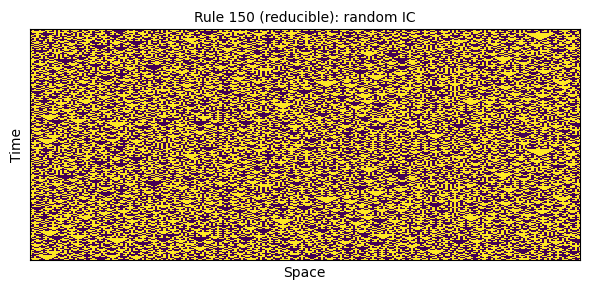

In [85]:
# --- Generate and save figures ---
out_files = []
settings = dict(width=256, steps=256, p_init=0.5, seed=42, init="random")

for rule, name in [(150, "Rule 150 (reducible)"),
                   ( 90, "Rule 90 (reducible)"),
                   ( 30, "Rule 30 (irreducible)")]:

    grid = simulate(rule, **settings)
    out = plot_spacetime(grid, f"{name}: random IC", f"/mnt/data/rule{rule}_spacetime_random.png")
    out_files.append(out)

# Also make single-seed (single 1 in the center) versions (useful for 150/90 triangles)
single_settings = dict(width=256, steps=256, seed=1, init="single")

for rule, name in [(150, "Rule 150 (reducible)"),
                   ( 90, "Rule 90 (reducible)"),
                   ( 30, "Rule 30 (irreducible)")]:

    grid = simulate(rule, **single_settings)
    out = plot_spacetime(grid, f"{name}: single-cell IC", f"/mnt/data/rule{rule}_spacetime_single.png")
    out_files.append(out)

out_files